# Results Plot

Plot the $\langle\sigma v\rangle$ upper limits for the combined analysis  
and for individual dwarf galaxies.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os


## ⚙️ Input Cell

In [2]:
CHANNEL      = 'b'     # must match files produced by Dwarf_Sigma_Calc
INITIAL_MASS = 500     # [GeV]

MASS_FILE   = 'mass.txt'
RESULTS_DIR = 'results/sigma'

# Dwarf names (same order as columns in sing_sigmav_*.txt)
DWARF_NAMES = [
    'Carina','Fornax','Leo I','Leo II','Sculptor',
    'Sextans','Bootes I','Coma','Hercules',
    'Leo IV','Leo V','Leo T','Segue 1','Segue 2'
]
COLORS = [
    'r','b','g','c','darkorange','gold','grey',
    'darkviolet','pink','olive','sienna','fuchsia','lightgreen','indigo'
]


## Load results

In [3]:
mass = np.loadtxt(MASS_FILE)
initial_mass_idx = list(mass).index(INITIAL_MASS)
mass_plot = mass[initial_mass_idx:] * 1e-3   # GeV → TeV

combined   = np.loadtxt(os.path.join(RESULTS_DIR, f'sigmav_{CHANNEL}.txt'))
sing_sigma = np.loadtxt(os.path.join(RESULTS_DIR, f'sing_sigmav_{CHANNEL}.txt'))

print(f"Combined limit shape : {combined.shape}")
print(f"Individual limit shape: {sing_sigma.shape}  (mass × dwarfs)")


Combined limit shape : (30,)
Individual limit shape: (30, 14)  (mass × dwarfs)


## Plot

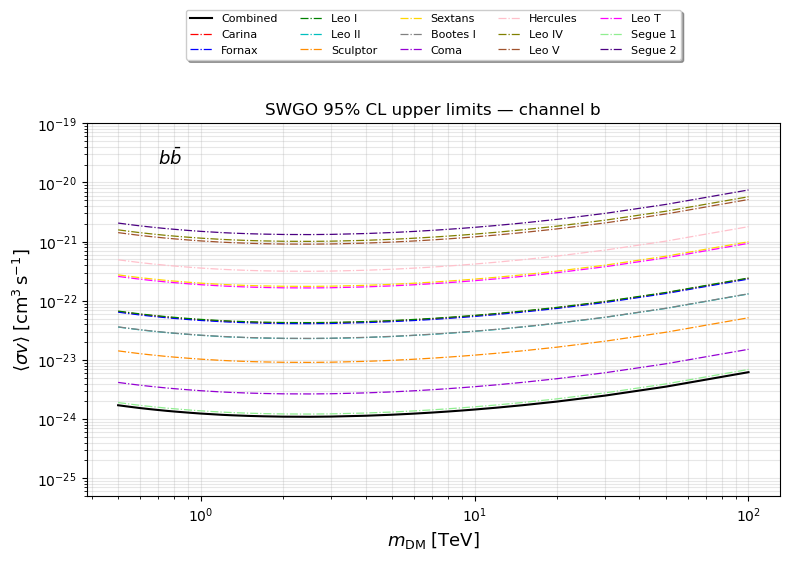

Plot saved to results/sigma/limits_b.{pdf,png}


In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

# Combined limit
ax.plot(mass_plot, combined, color='black', linewidth=1.5, label='Combined')

# Individual dwarfs
for i, (name, color) in enumerate(zip(DWARF_NAMES, COLORS)):
    ax.plot(mass_plot, sing_sigma[:, i],
            color=color, linestyle='-.', linewidth=0.9, label=name)

# Annotation
ax.text(0.7, 2e-20, r'$b\bar{b}$', fontsize=13, color='black')

ax.set_xlabel(r'$m_{\rm DM}\;[\rm TeV]$', fontsize=13)
ax.set_ylabel(r'$\langle\sigma v\rangle\;[\rm cm^3\,s^{-1}]$', fontsize=13)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim([5e-26, 1e-19])

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.32),
          ncol=5, fancybox=True, shadow=True, fontsize=8)
ax.set_title(f'SWGO 95% CL upper limits — channel {CHANNEL}', fontsize=12)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'limits_{CHANNEL}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_DIR, f'limits_{CHANNEL}.png'), bbox_inches='tight', dpi=150)
plt.show()
print(f"Plot saved to {RESULTS_DIR}/limits_{CHANNEL}.{{pdf,png}}")
